Null Hypothesis: The playcount per listener ratio is the same for artists who use AI and artists that dont use AI.

Alternative Hypothesis: Artists that use AI have lower playcount per listener ratio.

In [32]:
!pip install matplotlib==3.10.6 \
numpy==2.3.3\
pandas==2.3.3



---



In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve()
ENRICHED_PATH = DATA_DIR / "deezer_lastfm_enriched.csv"

if not ENRICHED_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at {ENRICHED_PATH}")

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.2f}".format



---



In [34]:
preview_lines = []
with ENRICHED_PATH.open() as f:
    for line in f:
        preview_lines.append(line.strip())
        if len(preview_lines) == 6:
            break

for line in preview_lines:
    print(line)


artist_id,artist_name,artist_nb_albums,artist_fans_deezer,album_id,album_title,album_url,release_date,nb_tracks,genre,deezer_fans,ai_flagged,ai_flag_text,scrape_error,search_query,lastfm_artist_found,lastfm_artist_name,artist_playcount,artist_listeners,artist_url,album_playcount,album_match_type,album_match_score
74069182,Sombre Ensemble,5,22,174228742,"Fête d'Halloween 2020: Ambiance effrayante avec bruits de fantômes, âmes damnées, clowns killer",https://www.deezer.com/en/album/174228742,2020-10-02,15,,52,False,,,ambient 2025,True,Sombre Ensemble,194,127,https://www.last.fm/music/Sombre+Ensemble,3,exact,100
103467092,Łil Cødeìnê,1,0,751670411,Soul (Live 2025),https://www.deezer.com/en/album/751670411,2025-04-26,1,Rap/Hip Hop,0,False,,,soul 2025,False,,,,,,no_tracks_found,0
1290704,Capoeira Experience,13,937,562325811,Capoeira Eletrônica 2024,https://www.deezer.com/en/album/562325811,2024-03-22,18,,19,False,,,electronic 2025,True,Capoeira Experience,22642,3090,https://www.last.fm/musi



---



In [35]:
mydata = pd.read_csv(ENRICHED_PATH)
mydata.head()
mydata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   artist_id            500 non-null    int64  
 1   artist_name          500 non-null    object 
 2   artist_nb_albums     500 non-null    int64  
 3   artist_fans_deezer   500 non-null    int64  
 4   album_id             500 non-null    int64  
 5   album_title          500 non-null    object 
 6   album_url            500 non-null    object 
 7   release_date         500 non-null    object 
 8   nb_tracks            500 non-null    int64  
 9   genre                432 non-null    object 
 10  deezer_fans          500 non-null    int64  
 11  ai_flagged           500 non-null    bool   
 12  ai_flag_text         86 non-null     object 
 13  scrape_error         1 non-null      object 
 14  search_query         500 non-null    object 
 15  lastfm_artist_found  500 non-null    boo



---



In [36]:
columns_of_interest = ["artist_name", "artist_fans_deezer", "lastfm_artist_name", "artist_listeners", "artist_playcount"]
summary = mydata[columns_of_interest].describe(include="all")
summary

,artist_name,artist_fans_deezer,lastfm_artist_name,artist_listeners,artist_playcount
count,500,500.00,453,453.00,453.00
unique,499,NaN,452,NaN,NaN
top,Çeşitli Sanatçılar,NaN,Çeşitli Sanatçılar,NaN,NaN
freq,2,NaN,2,NaN,NaN
mean,NaN,72072.55,NaN,103737.34,6701488.98
std,NaN,679003.03,NaN,526923.96,53810546.16
min,NaN,0.00,NaN,1.00,1.00
25%,NaN,1.00,NaN,24.00,101.00
50%,NaN,24.50,NaN,506.00,2974.00
75%,NaN,766.50,NaN,12058.00,127316.00




---



In [37]:
top_ai_artists = (
    mydata
    .query("ai_flagged == True and lastfm_artist_found == True")
    .sort_values(by="artist_listeners", ascending=False)
    .loc[:, ["artist_name", "album_title", "artist_fans_deezer", "artist_listeners", "artist_playcount"]]
    .head(5)
)
top_ai_artists

,artist_name,album_title,artist_fans_deezer,artist_listeners,artist_playcount
366,Ray,Dance Pop 2025,2361,119125.00,3157900.00
433,Happy Birthday Songs,Happy Birthday (Disco Pop Version 2025),399,46359.00,126968.00
340,Sissy,In My Soul (Remastered 2025),202,16125.00,201159.00
406,World Music,Türkçe Pop 2025,14509,9681.00,87485.00
44,Old Soul,Silent Night EDM 2025,233,7741.00,66099.00




---



In [38]:
top_non_ai_artists = (
    mydata
    .query("ai_flagged == False and lastfm_artist_found == True")
    .sort_values(by="artist_listeners", ascending=False)
    .loc[:, ["artist_name", "album_title", "artist_fans_deezer", "artist_listeners", "artist_playcount"]]
    .head(5)
)
top_non_ai_artists

,artist_name,album_title,artist_fans_deezer,artist_listeners,artist_playcount
159,Linkin Park,From Zero (Deluxe Edition),12045663,6914928.00,740469082.00
258,Pink Floyd,The Dark Side Of The Moon (Live at Wembley 197...,6736100,5541702.00,608171106.00
435,Prince,Pop Life (Extended Version) (2025 Remaster),1325937,3339586.00,103213921.00
142,Ray Charles,Ingredients In A Recipe For Soul (2025 Remaster),2913463,2834663.00,44644669.00
238,Hans Zimmer,Blade Runner 2049 (Original Motion Picture Sou...,2117077,2712086.00,144763149.00




---



In [39]:
ai_artist_avg_listeners= mydata.groupby("ai_flagged")["artist_listeners"].mean()
ai_artist_avg_listeners

,artist_listeners
ai_flagged,
False,121192.77
True,3173.25




---



In [40]:
listeners_summary_by_ai = mydata.groupby("ai_flagged")["artist_listeners"].agg(["mean", "median", "count"])
listeners_summary_by_ai

,mean,median,count
ai_flagged,,,
False,121192.77,1003.50,386
True,3173.25,20.00,67




---



In [41]:
playcount_summary_by_ai = mydata.groupby("ai_flagged")["artist_playcount"].agg(["mean", "median", "count"])
playcount_summary_by_ai

,mean,median,count
ai_flagged,,,
False,7855062.86,6781.00,386
True,55526.03,54.00,67


   

---








In [42]:
"""calculated the plays-per-listener ratio and added it as a new column to my dataset"""
mydata_with_ratio = mydata.assign(playcount_to_listener_ratio = mydata["artist_playcount"] / mydata["artist_listeners"])







---









In [43]:
ratio_summary_by_ai = mydata_with_ratio.groupby("ai_flagged")["playcount_to_listener_ratio"].agg(["mean", "median", "count"])
ratio_summary_by_ai

,mean,median,count
ai_flagged,,,
False,17.05,6.47,386
True,6.43,3.25,67




---



In [44]:
mydata_with_ratio_for_albums = mydata.assign(
    album_playcount_to_listener_ratio = mydata["album_playcount"] / mydata["artist_listeners"]
)

album_ratio_summary_by_ai = mydata_with_ratio_for_albums.groupby("ai_flagged")["album_playcount_to_listener_ratio"].agg(["mean", "median", "count"])
album_ratio_summary_by_ai

,mean,median,count
ai_flagged,,,
False,2.32,0.06,386
True,0.91,0.00,67


--------------------------------------------------------------------


# Plots


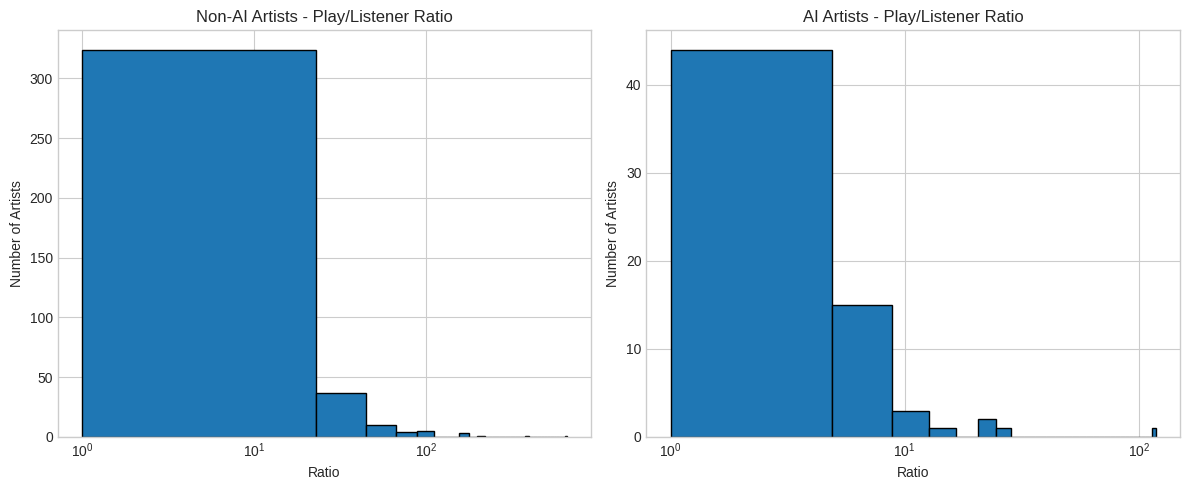

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2,figsize=(12,5))

for ax,flag,label in zip(axes, [False, True], ["Non-AI", "AI"]):
    subset = mydata_with_ratio[mydata_with_ratio["ai_flagged"]==flag]["playcount_to_listener_ratio"].dropna()
    ax.hist(subset, bins=30, edgecolor = 'black')
    ax.set_title(f"{label} Artists - Play/Listener Ratio")
    ax.set_xlabel("Ratio")
    ax.set_xscale("log")
    ax.set_ylabel("Number of Artists")

plt.tight_layout()
plt.show()


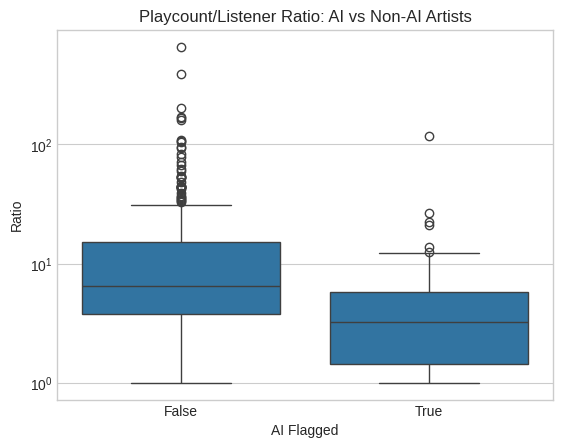

In [46]:
"""Boxplot"""

sns.boxplot(data = mydata_with_ratio, x="ai_flagged", y= "playcount_to_listener_ratio")
plt.title("Playcount/Listener Ratio: AI vs Non-AI Artists")
plt.xlabel("AI Flagged")
plt.ylabel("Ratio")
plt.yscale("log")

plt.show()

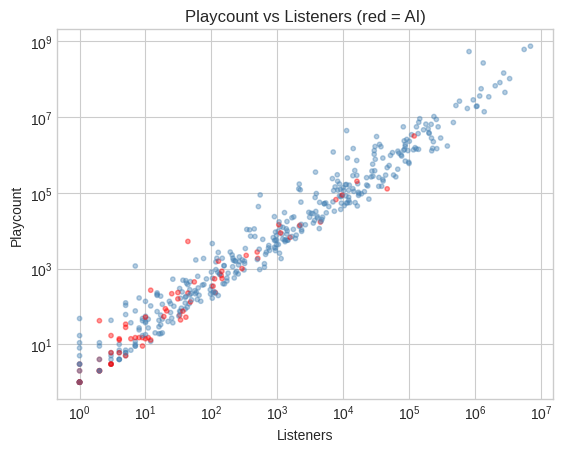

In [47]:
"""Scatter Plot"""

colors = mydata_with_ratio["ai_flagged"].map({True: "red", False: "steelblue"})
plt.scatter(mydata_with_ratio["artist_listeners"], mydata_with_ratio["artist_playcount"], c=colors, alpha=0.4, s=10)
plt.xlabel("Listeners")
plt.ylabel("Playcount")
plt.title("Playcount vs Listeners (red = AI)")
plt.xscale("log")
plt.yscale("log")
plt.show()


# ML Methods

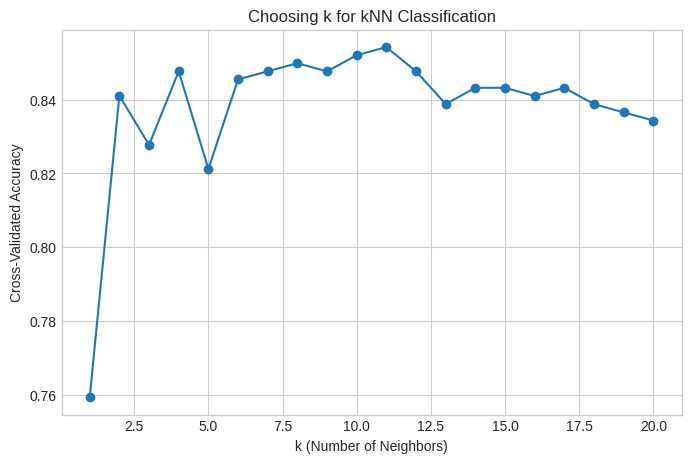

Best k: 11
              precision    recall  f1-score   support

           0       0.82      0.95      0.88        74
           1       0.33      0.12      0.17        17

    accuracy                           0.79        91
   macro avg       0.58      0.53      0.53        91
weighted avg       0.73      0.79      0.75        91



In [48]:
"""KNN"""


# Used the code from week 9 recitation

from sklearn.datasets import make_regression, make_classification
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report



features = ["artist_listeners", "artist_playcount", "artist_fans_deezer", "playcount_to_listener_ratio"]
df_ml = mydata_with_ratio[features + ["ai_flagged"]].dropna()
X_clf = df_ml[features].values
y_clf = df_ml["ai_flagged"].astype(int).values #converted true and false inputs into integers 1 and 0


#Used code from claude for KNN scaling operations with the prompt "integrate appropriate scaling operations for KNN"
scaler = StandardScaler()
X_clf = scaler.fit_transform(X_clf)

# Try different values of k
k_values = list(range(1, 21))
cv_scores = []



for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot k vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Choosing k for kNN Classification")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k}")



#Used code from Claude with the prompt "integrate a classification report with best k value"
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))


Note: The model can't detect AI artists accurately. Because the dataset doesnt contain enough AI artists making it imbalanced.  


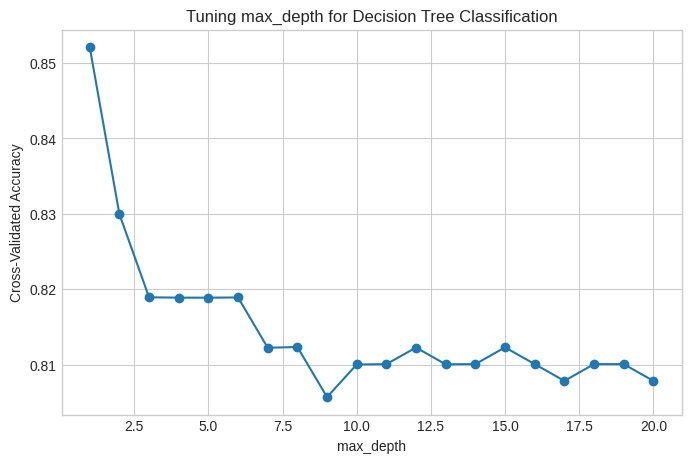

Best max_depth: 1
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        74
           1       0.00      0.00      0.00        17

    accuracy                           0.81        91
   macro avg       0.41      0.50      0.45        91
weighted avg       0.66      0.81      0.73        91



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
"""Decision Tree"""

# Used the code from week 9 recitation

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt



depths = list(range(1, 21))
cv_scores = []



for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=1)
    scores = cross_val_score(tree, X_clf, y_clf, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(depths, cv_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Tuning max_depth for Decision Tree Classification")
plt.grid(True)
plt.show()

best_depth = depths[np.argmax(cv_scores)]
print(f"Best max_depth: {best_depth}")




#Used code from Claude with the prompt "integrate a classification report"

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
final_tree.fit(X_train, y_train)
y_pred = final_tree.predict(X_test)

print(classification_report(y_test, y_pred))

Note: The decision tree scored even worse than KNN because of the imbalance in the dataset.

In [54]:
"""Random Forest"""
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.datasets import make_classification



depths = [3, 5, 10, 15]
estimators = [10, 50, 100]
results = {}

for d in depths:
    for n in estimators:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        score = cross_val_score(rf, X_clf, y_clf, cv=5, scoring='accuracy').mean()
        results[(d, n)] = score

best_params = max(results, key=results.get)
print(f"Best max_depth: {best_params[0]}, Best n_estimators: {best_params[1]}")
print(f"Best CV Accuracy: {results[best_params]:.2f}")


#Used code from Claude with the prompt "integrate a classification report"
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
final_rf = RandomForestClassifier(n_estimators=best_params[1], max_depth=best_params[0], random_state=42)
final_rf.fit(X_train, y_train)
y_pred = final_rf.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))


Best max_depth: 3, Best n_estimators: 10
Best CV Accuracy: 0.86
              precision    recall  f1-score   support

           0       0.85      0.99      0.91        74
           1       0.80      0.24      0.36        17

    accuracy                           0.85        91
   macro avg       0.82      0.61      0.64        91
weighted avg       0.84      0.85      0.81        91



In [61]:
"""Logistic Regression"""
#Used code from recitation 8

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # Probability of class 1



print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        74
           1       0.00      0.00      0.00        17

    accuracy                           0.81        91
   macro avg       0.41      0.50      0.45        91
weighted avg       0.66      0.81      0.73        91

Confusion Matrix:
[[74  0]
 [17  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
!git add .
!git commit -m "milestone2"
!git tag milestone2
!git push origin milestone2
!git config --global user.email "pelinumur05gmail.com"
!git config --global user.name "pelinumur-maker"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@0e8c9bf00d29.(none)')
fatal: tag 'milestone2' already exists
fatal: could not read Username for 'https://github.com': No such device or address


In [83]:
!git config --global user.email "pelinumur05gmail.com"
!git config --global user.name "pelinumur-maker"

In [84]:
!git add .
!git commit -m "milestone2"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [82]:
!git tag -d milestone2
!git tag milestone2

Deleted tag 'milestone2' (was 4233c81)


In [86]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
